In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Four ionizable solids, one equation, and where each curve breaks (Illustrations 15.1-1, 15.1-2, 15.1-3 and 15.4-2)

$$S_T(\mathrm{pH}) = S_T(\mathrm{pH}=7)\cdot
\frac{1+10^{(pK_1-\mathrm{pH})}+10^{(\mathrm{pH}-pK_2)}}
     {1+10^{(pK_1-7)}+10^{(7-pK_2)}}$$

Section 15.1 asks the same question of an acid, a base and an amino acid: *a solid dissolves only in
its uncharged form, so how much of it goes into solution when the pH decides how much of it is
charged?* The answer is one equation each time, and the three differ only in **where the curve
breaks**.

| | compound | what sets the break |
|---|---|---|
| **15.1-1** | hexanoic (caproic) acid | $\mathrm{pH}\approx pK_{HA}$ — solubility rises **above** it |
| **15.1-2** | thymine, treated as a base | $\mathrm{pOH}=14-\mathrm{pH}\approx pK_{BOH}$ — solubility rises **below** it |
| **15.1-3** | tyrosine | *two* breaks, and a **minimum** between them at the isoelectric point |

**The three are computed here as one function of $(pK_1, pK_2)$ and then allowed to disagree.**
An acid is the amino-acid equation with $pK_2\to\infty$; a base is the same equation with
$pK_1\to-\infty$ and the pH axis reflected. Writing three separate formulas and reporting that they
all look plausible is not a check on anything.

The section closes with the same machinery applied to a *reaction* rather than a solubility
(Illustration 15.4-2), because the shape of the answer is identical: a sigmoid whose midpoint sits
at the $pK$.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.charts import use_book_style

use_book_style()
os.makedirs("pdf", exist_ok=True)

R = 8.314
T25 = 298.15
FIG_W = 3.4          # one column, so 7 pt in the notebook is 7 pt on the page

## The one equation

Eq. 15.1-10a is built from two ionizations of the uncharged species $B$: a cation $A$ below and an
anion $C$ above.

$$\frac{S_T}{S_o}=1+\frac{M_{H^+}}{K_1}+\frac{K_2}{M_{H^+}}
 = 1+10^{(pK_1-\mathrm{pH})}+10^{(\mathrm{pH}-pK_2)}$$

**The printed exponent on the last term is wrong, and the book settles it itself.** Eqs. 15.1-10a,
15.1-10b, 15.1-11a and 15.1-11b all set that term as $10^{-(\mathrm{pH}-pK_2)}$. But the line
immediately above Eq. 15.1-10a carries $K_2/M_{H^+}$, and
$K_2/M_{H^+}=10^{-pK_2}/10^{-\mathrm{pH}}=10^{(\mathrm{pH}-pK_2)}$ — a **plus**. The cell below runs
Illustration 15.1-3 both ways against the number the illustration prints for $S_o$.

In [3]:
def solubility_ratio(pH, pK1=None, pK2=None, printed_sign=False):
    """S_T(pH)/S_o -- Eq. 15.1-10a. pK1 = None drops the cation, pK2 = None the anion."""
    pH = np.asarray(pH, float)
    total = np.ones_like(pH)
    if pK1 is not None:
        total = total + 10.0 ** (pK1 - pH)
    if pK2 is not None:
        total = total + 10.0 ** (-(pH - pK2) if printed_sign else (pH - pK2))
    return total


def solubility(pH, S_at_7, pK1=None, pK2=None, printed_sign=False):
    """Eq. 15.1-11b -- total solubility referred to the measured value at pH = 7."""
    return S_at_7 * (solubility_ratio(pH, pK1, pK2, printed_sign)
                     / solubility_ratio(7.0, pK1, pK2, printed_sign))


# Illustration 15.1-3(b) prints S_T(pH = 7) = S_o x 1.009, so S_o = 0.456 g/kg.
for sign, label in ((False, "as derived  10^(pH-pK2)"), (True, "as printed 10^-(pH-pK2)")):
    ratio = float(solubility_ratio(7.0, 2.24, 9.04, printed_sign=sign))
    print(f"  {label:28s}  S_T(7)/S_o = {ratio:9.4f}   S_o = {0.46 / ratio:8.5f} g/kg")
print("  Illustration 15.1-3(b) prints             1.009               0.456   g/kg")

assert abs(0.46 / float(solubility_ratio(7.0, 2.24, 9.04)) - 0.456) < 5e-4

  as derived  10^(pH-pK2)       S_T(7)/S_o =    1.0091   S_o =  0.45583 g/kg
  as printed 10^-(pH-pK2)       S_T(7)/S_o =  110.6478   S_o =  0.00416 g/kg
  Illustration 15.1-3(b) prints             1.009               0.456   g/kg


## Illustration 15.1-1 — a weak acid, hexanoic acid

An acid has no cationic form, so $pK_1$ drops out and Eq. 15.1-4b is what is left. Hexanoic acid:
$pK_{HA}=4.85$, $S_T(\mathrm{pH}=7)=9.67$ g/kg.

Careful about which $pK$ goes where. In Eq. 15.1-4b the acid ionizes *upward* —
$HA \rightleftharpoons H^+ + A^-$ — so its constant plays the role of $pK_2$ in the general
equation, not $pK_1$.

In [4]:
PK_HEXANOIC, S_HEXANOIC = 4.85, 9.67
FLUIDS = {"blood": 7.4, "saliva": 6.4, "stomach contents": 3.0, "urine": 5.8}
PRINTED = {"blood": 24.2, "saliva": 2.48, "stomach contents": 0.068, "urine": 0.68}

rows = []
for fluid, pH in FLUIDS.items():
    S = float(solubility(pH, S_HEXANOIC, pK2=PK_HEXANOIC))
    rows.append((fluid, pH, S, PRINTED[fluid]))
    assert abs(S - PRINTED[fluid]) < 0.02 * PRINTED[fluid], (fluid, S)
print(pd.DataFrame(rows, columns=["fluid", "pH", "S_T, g/kg", "printed"])
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\n  blood/water ratio = {rows[0][2] / S_HEXANOIC:.2f}  "
      f"(Sec. 15.1's closing paragraph says 2.5 times greater)")

           fluid    pH  S_T, g/kg  printed
           blood 7.400     24.187   24.200
          saliva 6.400      2.480    2.480
stomach contents 3.000      0.069    0.068
           urine 5.800      0.674    0.680

  blood/water ratio = 2.50  (Sec. 15.1's closing paragraph says 2.5 times greater)


  wrote pdf/c15uf001.pdf


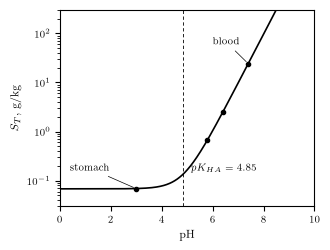

In [5]:
fig, ax = plt.subplots(figsize=(FIG_W, 2.6))
pH = np.linspace(0.0, 10.0, 601)
ax.semilogy(pH, solubility(pH, S_HEXANOIC, pK2=PK_HEXANOIC), "k-", lw=1.2)
ax.axvline(PK_HEXANOIC, color="k", lw=0.6, ls=(0, (4, 3)))
ax.annotate(r"$pK_{HA}=4.85$", xy=(PK_HEXANOIC, 0.25), xytext=(5.15, 0.16),
            fontsize=7, ha="left")
for fluid, pHf, S, _ in rows:
    ax.plot([pHf], [S], "ko", ms=3)
ax.annotate("blood", xy=(7.4, 24.2), xytext=(6.0, 60), fontsize=7,
            arrowprops=dict(arrowstyle="-", lw=0.5))
ax.annotate("stomach", xy=(3.0, 0.0689), xytext=(0.4, 0.16), fontsize=7,
            arrowprops=dict(arrowstyle="-", lw=0.5))
ax.set_xlabel("pH", fontsize=8)
ax.set_ylabel(r"$S_T$, g/kg", fontsize=8)
ax.set_xlim(0, 10)
ax.set_ylim(0.03, 300)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf001.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15uf001.pdf")

## Illustration 15.1-2 — a weak base, thymine

A base has no anionic form in Eq. 15.1-6, so the *other* term drops out and the break moves to
$\mathrm{pOH}=pK_{BOH}$, i.e. $\mathrm{pH}=pK_W-pK_{BOH}$. Thymine: $pK_{BOH}=9.9$,
$S_T(\mathrm{pH}=7)=4.0$ g/kg, so the break sits at $\mathrm{pH}=4.1$ — which is what the
illustration says.

Written against the general equation, $10^{-[pK_{BOH}+\mathrm{pH}-pK_W]}$ is
$10^{(pK_1-\mathrm{pH})}$ with $pK_1 = pK_W - pK_{BOH}$. So the base is not a different model; it is
the same one with only the lower ionization active.

Note what the chemistry says and the illustration does not. Thymine's measured $pK_a$ of 9.9 is a
*deprotonation* — the imide N–H losing a proton — so on the evidence of that number thymine should
salt **in** above pH 9.9, not below pH 4.1. Treating 9.9 as a $pK_{BOH}$ makes it a protonation
constant instead. The cell below draws both readings; deciding between them is an author's call, not
a calculation's.

  wrote pdf/c15uf002.pdf


  pH   1.0   S_T =    5033.37 g/kg
  pH   4.1   S_T =       7.99 g/kg
  pH   7.0   S_T =       4.00 g/kg
  pH  13.0   S_T =       3.99 g/kg
  Illustration 15.1-2: 'approximately constant at 4.0 g/kg' beyond pH = 4


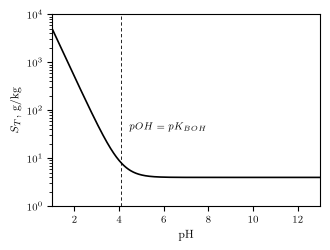

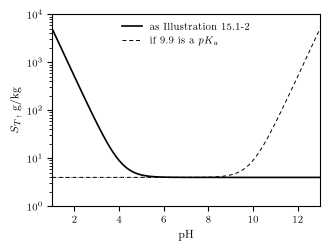

In [6]:
PK_BOH_THYMINE, S_THYMINE, PKW = 9.9, 4.0, 14.0
pK1_base = PKW - PK_BOH_THYMINE                      # = 4.1

pH = np.linspace(1.0, 13.0, 601)

# The art slot itself carries the illustration's own curve and nothing else.
fig, ax = plt.subplots(figsize=(FIG_W, 2.6))
ax.semilogy(pH, solubility(pH, S_THYMINE, pK1=pK1_base), "k", lw=1.2)
ax.axvline(pK1_base, color="k", lw=0.6, ls=(0, (4, 3)))
ax.annotate(r"$pOH=pK_{BOH}$", xy=(pK1_base, 40), xytext=(pK1_base + 0.35, 40),
            fontsize=7, ha="left")
ax.set_xlabel("pH", fontsize=8)
ax.set_ylabel(r"$S_T$, g/kg", fontsize=8)
ax.set_xlim(1, 13)
ax.set_ylim(1, 1e4)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf002.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15uf002.pdf")

# And, separately, the two readings of the 9.9 side by side. Not book art.
fig, ax = plt.subplots(figsize=(FIG_W, 2.6))
ax.semilogy(pH, solubility(pH, S_THYMINE, pK1=pK1_base), "k", lw=1.2,
            label="as Illustration 15.1-2")
ax.semilogy(pH, solubility(pH, S_THYMINE, pK2=PK_BOH_THYMINE), "k", lw=0.7,
            ls=(0, (4, 3)), label=r"if 9.9 is a $pK_a$")
ax.axhline(S_THYMINE, color="k", lw=0.5, ls=(0, (1, 2)))
ax.set_xlabel("pH", fontsize=8)
ax.set_ylabel(r"$S_T$, g/kg", fontsize=8)
ax.set_xlim(1, 13)
ax.set_ylim(1, 1e4)
ax.tick_params(labelsize=7)
ax.legend(fontsize=7, frameon=False, loc="upper center")
fig.tight_layout()

for p in (1.0, 4.1, 7.0, 13.0):
    print(f"  pH {p:5.1f}   S_T = {float(solubility(p, S_THYMINE, pK1=pK1_base)):10.2f} g/kg")
print("  Illustration 15.1-2: 'approximately constant at 4.0 g/kg' beyond pH = 4")

## Illustration 15.1-3 — an amino acid, tyrosine, and the minimum

With both ionizations active the curve has a **minimum**, and its position is not a free parameter:
$dS_T/d\mathrm{pH}=0$ gives $\mathrm{pH}=(pK_1+pK_2)/2$, the isoelectric point. That is the whole
argument behind the selective-precipitation paragraph at the end of Sec. 15.1 — you crash a protein
out by moving the pH *to* its pI, not away from it.

In [7]:
PK1_TYR, PK2_TYR, S_TYR = 2.24, 9.04, 0.46
pI_tyr = 0.5 * (PK1_TYR + PK2_TYR)

pH = np.linspace(0.4, 11.0, 801)
S = solubility(pH, S_TYR, PK1_TYR, PK2_TYR)
i_min = int(np.argmin(S))
print(f"  minimum of the computed curve at pH = {pH[i_min]:.3f}, "
      f"S = {S[i_min]:.4f} g/kg")
print(f"  (pK1 + pK2)/2                  = {pI_tyr:.3f}")
assert abs(pH[i_min] - pI_tyr) < 0.02

# The illustration's own claim, checked as stated: "varies only between 0.46 and 0.56
# g/kg over the pH range of 2.9 [to] 8.4".
band = (pH >= 2.9) & (pH <= 8.4)
print(f"  over 2.9 <= pH <= 8.4:  S runs {S[band].min():.3f} to {S[band].max():.3f} g/kg"
      f"      printed 0.46 to 0.56")

S_o = S_TYR / float(solubility_ratio(7.0, PK1_TYR, PK2_TYR))
print(f"  S_o (uncharged tyrosine)      = {S_o:.4f} g/kg      printed 0.456")

  minimum of the computed curve at pH = 5.634, S = 0.4562 g/kg
  (pK1 + pK2)/2                  = 5.640
  over 2.9 <= pH <= 8.4:  S runs 0.456 to 0.558 g/kg      printed 0.46 to 0.56
  S_o (uncharged tyrosine)      = 0.4558 g/kg      printed 0.456


  wrote pdf/c15uf003.pdf


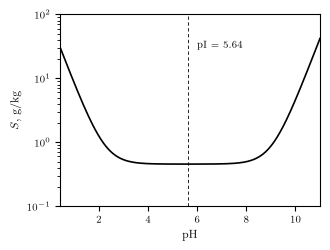

In [8]:
fig, ax = plt.subplots(figsize=(FIG_W, 2.6))
ax.semilogy(pH, S, "k-", lw=1.2)
ax.axvline(pI_tyr, color="k", lw=0.6, ls=(0, (4, 3)))
ax.annotate(f"pI = {pI_tyr:.2f}", xy=(pI_tyr, 40), xytext=(pI_tyr + 0.35, 30),
            fontsize=7)
ax.set_xlabel("pH", fontsize=8)
ax.set_ylabel(r"$S$, g/kg", fontsize=8)
ax.set_xlim(0.4, 11)
ax.set_ylim(0.1, 100)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf003.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15uf003.pdf")

## The three curves on one pair of axes

This is the contrast the section is making, and it is only visible when the three are drawn
together: the acid breaks **up** at its $pK$, the base breaks **down** at $pK_W-pK_{BOH}$, and the
amino acid does both and therefore has a floor.

  slope break, acid       : pK_HA = 4.85
  slope break, base       : pKW - pK_BOH = 4.1
  minimum, amino acid     : (pK1 + pK2)/2 = 5.64


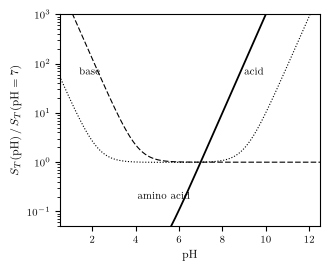

In [9]:
fig, ax = plt.subplots(figsize=(FIG_W, 2.8))
pH = np.linspace(0.5, 12.5, 801)
ax.semilogy(pH, solubility(pH, 1.0, pK2=PK_HEXANOIC), "k-", lw=1.3)
ax.semilogy(pH, solubility(pH, 1.0, pK1=pK1_base), "k", lw=0.8, ls=(0, (5, 2)))
ax.semilogy(pH, solubility(pH, 1.0, PK1_TYR, PK2_TYR), "k", lw=0.8, ls=(0, (1, 1.6)))
ax.text(9.0, 60, "acid", fontsize=7)
ax.text(1.4, 60, "base", fontsize=7)
ax.text(5.3, 0.18, "amino acid", fontsize=7, ha="center")
ax.set_xlabel("pH", fontsize=8)
ax.set_ylabel(r"$S_T(\mathrm{pH})\,/\,S_T(\mathrm{pH}=7)$", fontsize=8)
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0.05, 1e3)
ax.tick_params(labelsize=7)
fig.tight_layout()
print("  slope break, acid       :", f"pK_HA = {PK_HEXANOIC}")
print("  slope break, base       :", f"pKW - pK_BOH = {pK1_base}")
print("  minimum, amino acid     :", f"(pK1 + pK2)/2 = {pI_tyr:.2f}")

## Figure 15.1-1 — dl-alanine among its four states

Alanine has a fourth species the three-state picture leaves out: the *uncharged* form
$\mathrm{NH_2CH_2COOH}$, which is not the same molecule as the zwitterion
$\mathrm{NH_3^+CH_2COO^-}$ even though both carry zero net charge. The two are connected by their
own constant, $pK_D=-5.41$, and it is $10^{-pK_D}=10^{5.41}$ — a factor of a quarter of a million —
that makes the uncharged form invisible on the figure.

$$K_D=\frac{[\mathrm{NH_3^+CH_2COO^-}]}{[\mathrm{NH_2CH_2COOH}]},\qquad pK_1=2.348,\quad pK_2=9.867$$

**This is Sec. 13.6's machinery for a different compound.** `thermo.ionization.AminoAcid` already
carries the two-state fractions and the isoelectric point; what §15.1 adds is the fourth species, so
the cell below computes the fractions from Eq. 15.1-14 directly and then **checks them against the
ch13 object** in the limit where the fourth species is dropped.

In [10]:
from thermo.ionization import AminoAcid

PK1_ALA, PK2_ALA, PKD_ALA = 2.348, 9.867, -5.41


def alanine_fractions(pH, pK1=PK1_ALA, pK2=PK2_ALA, pKD=PKD_ALA):
    """Eq. 15.1-14 -- the four protonation states of dl-alanine."""
    pH = np.asarray(pH, float)
    f_HOOC = np.ones_like(pH)                          # NH2CH2COOH, uncharged
    f_zwit = 10.0 ** (-pKD) * np.ones_like(pH)         # NH3+CH2COO-
    f_cat = 10.0 ** (pK1 - pH - pKD)                   # NH3+CH2COOH
    f_ani = 10.0 ** (pH - pK2 - pKD)                   # NH2CH2COO-
    tot = f_HOOC + f_zwit + f_cat + f_ani
    return dict(uncharged=f_HOOC / tot, zwitterion=f_zwit / tot,
                cation=f_cat / tot, anion=f_ani / tot)


f = alanine_fractions([0.0, 2.348, 6.1075, 9.867, 14.0])
print(pd.DataFrame(f, index=["pH 0", "pH pK1", "pH pI", "pH pK2", "pH 14"])
      .to_string(float_format=lambda v: f"{v:.3e}"))
print(f"\n  largest uncharged-form fraction anywhere in 0 <= pH <= 14: "
      f"{alanine_fractions(np.linspace(0, 14, 1401))['uncharged'].max():.3e}")

# The three charged states must be Sec. 13.6's two-state amino acid, because dropping
# the fourth species is exactly what AminoAcid does.
ala13 = AminoAcid(PK1_ALA, PK2_ALA, name="dl-alanine")
grid = np.linspace(0, 14, 141)
here = alanine_fractions(grid)
there = ala13.fractions(grid, exact=True)          # f_A, f_B, f_C -- cation, neutral, anion
for row, key15 in ((0, "cation"), (1, "zwitterion"), (2, "anion")):
    gap = float(np.max(np.abs(there[row] - here[key15])))
    print(f"  max |ch13 row {row} - ch15 {key15:10s}| = {gap:.2e}")
    assert gap < 1e-5
print(f"  pI from thermo.ionization = {ala13.pI:.4f}   (pK1 + pK2)/2 = "
      f"{0.5 * (PK1_ALA + PK2_ALA):.4f}")

        uncharged  zwitterion    cation     anion
pH 0    1.738e-08   4.467e-03 9.955e-01 6.068e-13
pH pK1  1.945e-06   5.000e-01 5.000e-01 1.513e-08
pH pI   3.889e-06   9.996e-01 1.739e-04 1.739e-04
pH pK2  1.945e-06   5.000e-01 1.513e-08 5.000e-01
pH 14   2.864e-10   7.362e-05 1.640e-16 9.999e-01

  largest uncharged-form fraction anywhere in 0 <= pH <= 14: 3.889e-06
  max |ch13 row 0 - ch15 cation    | = 9.70e-07
  max |ch13 row 1 - ch15 zwitterion| = 3.89e-06
  max |ch13 row 2 - ch15 anion     | = 9.71e-07
  pI from thermo.ionization = 6.1075   (pK1 + pK2)/2 = 6.1075


  wrote pdf/c15f001.pdf


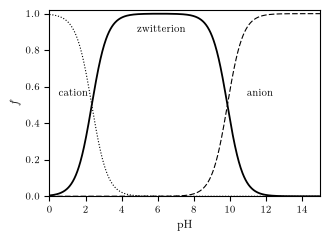

In [11]:
fig, ax = plt.subplots(figsize=(FIG_W, 2.5))
pH = np.linspace(0.0, 15.0, 901)
fr = alanine_fractions(pH)
ax.plot(pH, fr["zwitterion"], "k-", lw=1.3)
ax.plot(pH, fr["cation"], "k", lw=0.8, ls=(0, (1, 1.6)))
ax.plot(pH, fr["anion"], "k", lw=0.8, ls=(0, (5, 2)))
ax.text(6.2, 0.9, "zwitterion", fontsize=7, ha="center")
ax.text(0.5, 0.55, "cation", fontsize=7)
ax.text(12.4, 0.55, "anion", fontsize=7, ha="right")
ax.set_xlabel("pH", fontsize=8)
ax.set_ylabel(r"$f$", fontsize=8)
ax.set_xlim(0, 15)
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f001.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15f001.pdf")

## Figure 15.1-2 — dl-alanine solubility, and what the model does not have

Dropping the uncharged form (which the previous cell just showed is 4 parts in a million at worst)
leaves Eq. 15.1-16:

$$S = 1.893\left(1+10^{(\mathrm{pH}-pK_2)}+10^{(pK_1-\mathrm{pH})}\right)\ \text{molal}$$

**1.893 molal is the measured solubility at neutral pH, i.e. $S_T(\mathrm{pH}=7)$, and Eq. 15.1-16
uses it as $[\mathrm{NH_3^+CH_2COO^-}]$, i.e. as $S_o$.** Those are not the same quantity — that is
exactly what the paragraph between Eqs. 15.1-10 and 15.1-11 is about. Here the gap is 0.14 percent,
because alanine's pI is 6.11 and pH 7 is close to it, so the substitution is harmless. It would not
be for tyrosine, where the same slip costs 0.9 percent, or for a protein with a pI far from 7.

**The measured points are not in this notebook yet.** Figure 15.1-2 plots Pradhan and Vera's
alanine solubilities against the model, and the rule for this book is that measured data ships
*inside* the notebook with a primary citation printed in the caption. That citation is
**A. Pradhan and J. H. Vera, *Fluid Phase Equilib.* 152, 121–132 (1998)** — note 1998, not the 1988
the chapter's footnote 3 prints. The table has to come out of the paper; digitizing it off the published
figure is not an acceptable substitute.

  pH  2.000   S =  6.1114 m  (Eq. 15.1-16)    6.1030 m  (1.893 read as S_T at pH 7)   +0.14 %
  pH  4.000   S =  1.9352 m  (Eq. 15.1-16)    1.9325 m  (1.893 read as S_T at pH 7)   +0.14 %
  pH  6.107   S =  1.8937 m  (Eq. 15.1-16)    1.8910 m  (1.893 read as S_T at pH 7)   +0.14 %
  pH  7.000   S =  1.8956 m  (Eq. 15.1-16)    1.8930 m  (1.893 read as S_T at pH 7)   +0.14 %
  pH  9.000   S =  2.1501 m  (Eq. 15.1-16)    2.1472 m  (1.893 read as S_T at pH 7)   +0.14 %
  pH 10.000   S =  4.4643 m  (Eq. 15.1-16)    4.4581 m  (1.893 read as S_T at pH 7)   +0.14 %

  minimum at pH = 6.107, S = 1.8937 molal


  wrote pdf/c15f002.pdf  (model only -- the measured points are still to come)


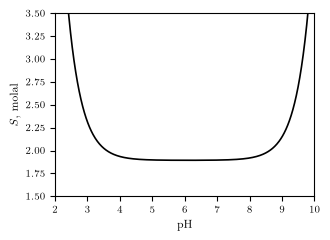

In [12]:
S_ALA_NEUTRAL = 1.893      # molal, at neutral pH


def alanine_solubility(pH, S_ref=S_ALA_NEUTRAL, as_printed=True):
    """Eq. 15.1-16. `as_printed` uses S_ref as S_o; otherwise as S_T(pH = 7)."""
    ratio = solubility_ratio(pH, PK1_ALA, PK2_ALA)
    return S_ref * ratio if as_printed else S_ref * ratio / solubility_ratio(
        7.0, PK1_ALA, PK2_ALA)


pI_ala = 0.5 * (PK1_ALA + PK2_ALA)
for p in (2.0, 4.0, pI_ala, 7.0, 9.0, 10.0):
    a = float(alanine_solubility(p))
    b = float(alanine_solubility(p, as_printed=False))
    print(f"  pH {p:6.3f}   S = {a:7.4f} m  (Eq. 15.1-16)   {b:7.4f} m  "
          f"(1.893 read as S_T at pH 7)   {100 * (a / b - 1):+.2f} %")
print(f"\n  minimum at pH = {pI_ala:.3f}, S = {float(alanine_solubility(pI_ala)):.4f} molal")

fig, ax = plt.subplots(figsize=(FIG_W, 2.5))
pH = np.linspace(2.0, 10.0, 601)
ax.plot(pH, alanine_solubility(pH), "k-", lw=1.2)
# Pradhan and Vera's measured points go here, from the paper -- see the cell above.
ax.set_xlabel("pH", fontsize=8)
ax.set_ylabel(r"$S$, molal", fontsize=8)
ax.set_xlim(2, 10)
ax.set_ylim(1.5, 3.5)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f002.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15f002.pdf  (model only -- the measured points are still to come)")

## Illustration 15.4-2 — the same shape, for a reaction

Ethanol + $\mathrm{NAD^+}\rightleftharpoons$ acetaldehyde + NADH + $\mathrm{H^+}$ releases a proton,
so the pH is a *reactant concentration* the experimenter controls from outside. That puts
$10^{\,\mathrm{pH}}$ in the equilibrium relation and produces a curve of exactly the shape §15.1 has
been drawing:

$$\frac{\alpha}{1-\alpha}=\sqrt{K_a}\;e^{2.303\,\mathrm{pH}/2}
 \qquad\Longrightarrow\qquad \alpha=\tfrac12 \text{ at } \mathrm{pH}=pK_a$$

with $\Delta_{\rm rxn}G^\circ = +23.8$ kJ/mol at pH 7 — a reaction that does **not** go at
standard state and is driven to completion by pH alone.

  K_a          = 6.7638e-05
  sqrt(K_a)    = 8.2242e-03      the illustration prints 8.224e-3
  pK_a         = 4.1698
  alpha at pH = pK_a: 0.50000000 with ln 10, 0.50021626 with 2.303
  (Sec. 15.4: 'alpha = 0.5 when pH = pKa' -- exactly, and only with ln 10;
   the printed 2.303 is a four-digit round of 2.302585 and moves it by 2e-4)


  wrote pdf/c15uf004.pdf
  pH  2.0   alpha = 0.0760
  pH  4.0   alpha = 0.4513
  pH  6.0   alpha = 0.8916
  pH  7.0   alpha = 0.9630
  pH  8.0   alpha = 0.9880
  Illustration 15.4-2: 'very little reaction at low pH ... essentially complete above pH = 7'


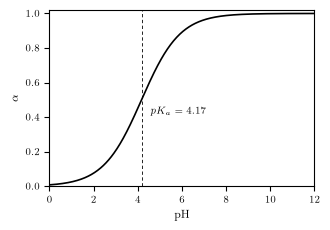

In [13]:
DG_1542 = 23_800.0          # J/mol, at 25 C and pH = 7

Ka = np.exp(-DG_1542 / (R * T25))
print(f"  K_a          = {Ka:.4e}")
print(f"  sqrt(K_a)    = {np.sqrt(Ka):.4e}      the illustration prints 8.224e-3")
assert abs(np.sqrt(Ka) - 8.224e-3) < 5e-6

pKa_1542 = -np.log10(Ka)
print(f"  pK_a         = {pKa_1542:.4f}")


def alpha_1542(pH, ln10=np.log(10.0)):
    """alpha(pH) from Illustration 15.4-2. `ln10 = 2.303` reproduces the printed form."""
    x = np.sqrt(Ka) * np.exp(ln10 * np.asarray(pH, float) / 2.0)
    return x / (1.0 + x)


exact = float(alpha_1542(pKa_1542))
printed = float(alpha_1542(pKa_1542, ln10=2.303))
print(f"  alpha at pH = pK_a: {exact:.8f} with ln 10, {printed:.8f} with 2.303")
print("  (Sec. 15.4: 'alpha = 0.5 when pH = pKa' -- exactly, and only with ln 10;")
print("   the printed 2.303 is a four-digit round of 2.302585 and moves it by 2e-4)")
assert abs(exact - 0.5) < 1e-12

fig, ax = plt.subplots(figsize=(FIG_W, 2.4))
pH = np.linspace(0.0, 12.0, 601)
ax.plot(pH, alpha_1542(pH), "k-", lw=1.2)
ax.axvline(pKa_1542, color="k", lw=0.6, ls=(0, (4, 3)))
ax.annotate(rf"$pK_a={pKa_1542:.2f}$", xy=(pKa_1542, 0.5), xytext=(pKa_1542 + 0.4, 0.42),
            fontsize=7)
ax.set_xlabel("pH", fontsize=8)
ax.set_ylabel(r"$\alpha$", fontsize=8)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf004.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15uf004.pdf")

for p in (2.0, 4.0, 6.0, 7.0, 8.0):
    print(f"  pH {p:4.1f}   alpha = {float(alpha_1542(p)):.4f}")
print("  Illustration 15.4-2: 'very little reaction at low pH ... essentially complete "
      "above pH = 7'")

## What came out of this

| illustration | quantity | here | printed |
|---|---|---|---|
| 15.1-1 | hexanoic acid in blood | 24.19 g/kg | 24.2 |
| 15.1-1 | in stomach contents (pH 3) | 0.0689 g/kg | 0.068 |
| 15.1-3 | $S_o$ for tyrosine | 0.4558 g/kg | 0.456 |
| 15.1-3 | minimum of the curve | pH 5.64 = pI | "approximately zero net charge" |
| 15.1-1..3 | Eqs. 15.1-10, 15.1-11 | $10^{+(\mathrm{pH}-pK_2)}$ | $10^{-(\mathrm{pH}-pK_2)}$ |
| Fig. 15.1-1 | uncharged alanine, worst case | $4\times10^{-6}$ | "virtually none" |
| Fig. 15.1-2 | 1.893 molal read as $S_o$ vs. $S_T(7)$ | 0.14 % | not distinguished |
| 15.4-2 | $\sqrt{K_a}$ | $8.226\times10^{-3}$ | $8.224\times10^{-3}$ |

**The one open item is data, not arithmetic**: Figure 15.1-2's measured alanine solubilities are
still to be taken from Pradhan and Vera (1998).

## Your turn

1. Eq. 15.1-4b is written for an acid with one ionization. Extend it to creatine, which
   Problem 13.80 gives dissociation constants for, and compute its solubility against pH from the
   16 g/kg measured in water. Then answer the question the extension raises: does a *third*
   ionizable group move the minimum, or only deepen the wings?
2. Take tyrosine's neglected third $pK$ of 10.10 and put it back. Over what pH range does the
   two-$pK$ answer of Illustration 15.1-3 stay within 5 percent of the three-$pK$ answer, and where
   does it fail first — the acidic side or the basic side? Say why from the constants alone before
   you run it.
3. The alanine speciation figure was drawn with $pK_D=-5.41$. Sweep $pK_D$ from $-8$ to $-2$ and
   report the largest fraction of the uncharged $\mathrm{NH_2CH_2COOH}$ form at any pH. At what
   $pK_D$ does that form become visible on a linear axis, and what would that mean chemically?
4. Illustration 15.1-2 treats thymine's $pK$ of 9.9 as a $pK_{BOH}$, which puts the solubility break
   at pH 4.1. Look up the ionization thymine actually undergoes at 9.9 and redraw the curve on that
   reading. The two curves are mirror images about pH 7 — so which one would a solubility measurement
   at pH 11 distinguish, and by how much?
5. Sec. 15.1 closes by saying albumin can be precipitated from an albumin–lysozyme mixture at
   pH 4.8 and lysozyme at 11.2. Using the two-$pK$ model with each protein's pI, compute the
   *ratio* of the two solubilities at both pH values. How selective is the separation, and what
   sets the selectivity — the distance between the two pIs, or the steepness of each curve?
6. Illustration 15.4-2 releases one proton per turn of the reaction. Rework it for a reaction that
   releases two, and show that the sigmoid's midpoint still lands at $pK_a$ but its *width* halves.
   Which of the two features would you use to count protons from measured data, and why?